In [1]:
# 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [5]:
# 2: Load cleaned encoded dataset
df = pd.read_csv("../data/telco_churn_cleaned_encoded.csv")

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


In [6]:
df.shape

(7043, 31)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7043 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  MultipleLines_Y

In [8]:
# 3: Check missing values before sampling
missing_values = df.isnull().sum().sum()

print("Total missing values:", missing_values)

Total missing values: 0


In [9]:
# 4: Separate features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 30)
Target shape: (7043,)


In [10]:
# 5: Analyze class distribution
class_counts = y.value_counts()
class_percentages = y.value_counts(normalize=True) * 100

print("Class Counts:")
print(class_counts)

print("\nClass Percentages:")
print(class_percentages)

Class Counts:
Churn
0    5174
1    1869
Name: count, dtype: int64

Class Percentages:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [12]:
# More clearly:
class_summary = pd.DataFrame({
    "Class": ["No Churn", "Churn"],
    "Count": [class_counts[0], class_counts[1]],
    "Percentage": [class_percentages[0], class_percentages[1]]
})

class_summary

,Class,Count,Percentage
0,No Churn,5174,73.463013
1,Churn,1869,26.536987


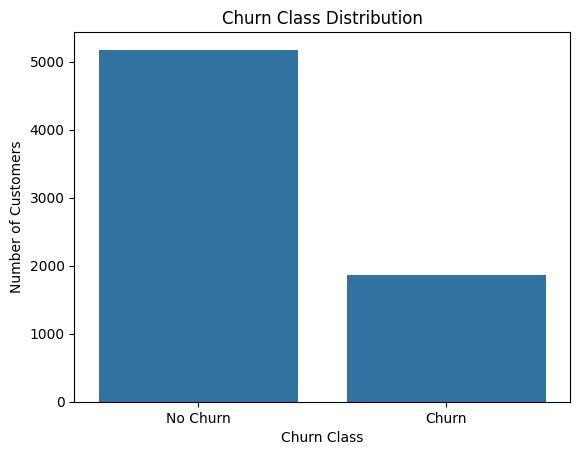

In [13]:
# 6: Visualize class distribution
sns.countplot(x=y)
plt.title("Churn Class Distribution")
plt.xlabel("Churn Class")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ["No Churn", "Churn"])
plt.show()

In [14]:
# 7: Comment on balance/imbalance
majority_class_percentage = class_percentages.max()
minority_class_percentage = class_percentages.min()

print("Majority class percentage:", round(majority_class_percentage, 2), "%")
print("Minority class percentage:", round(minority_class_percentage, 2), "%")

if majority_class_percentage > 60:
    print("The dataset is imbalanced.")
else:
    print("The dataset is relatively balanced.")

Majority class percentage: 73.46 %
Minority class percentage: 26.54 %
The dataset is imbalanced.


In [15]:
# 8: Split dataset into training and testing sets
# 70% training
# 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y # to preserve the same class distribution in both sets.
)

In [16]:
# 9: Check split sizes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4930, 30)
X_test shape: (2113, 30)
y_train shape: (4930,)
y_test shape: (2113,)


In [17]:
# 10: Verify class distribution after splitting
train_distribution = y_train.value_counts(normalize=True) * 100
test_distribution = y_test.value_counts(normalize=True) * 100

print("Training Set Class Distribution:")
print(train_distribution)

print("\nTesting Set Class Distribution:")
print(test_distribution)

Training Set Class Distribution:
Churn
0    73.46856
1    26.53144
Name: proportion, dtype: float64

Testing Set Class Distribution:
Churn
0    73.450071
1    26.549929
Name: proportion, dtype: float64


In [19]:
# Comparasion Table
split_distribution = pd.DataFrame({
    "Original Dataset (%)": y.value_counts(normalize=True) * 100,
    "Training Set (%)": y_train.value_counts(normalize=True) * 100,
    "Testing Set (%)": y_test.value_counts(normalize=True) * 100
})

split_distribution.index = ["No Churn", "Churn"]

split_distribution

,Original Dataset (%),Training Set (%),Testing Set (%)
No Churn,73.463013,73.46856,73.450071
Churn,26.536987,26.53144,26.549929


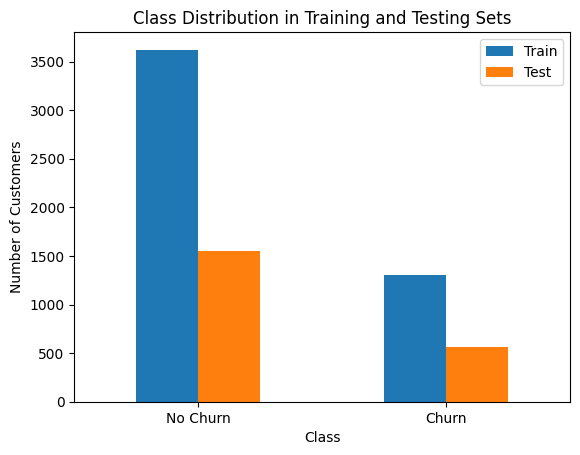

In [20]:
# 11: Visualize train/test class distribution
train_counts = y_train.value_counts().sort_index()
test_counts = y_test.value_counts().sort_index()

distribution_df = pd.DataFrame({
    "Train": train_counts,
    "Test": test_counts
})

distribution_df.index = ["No Churn", "Churn"]

distribution_df.plot(kind="bar")
plt.title("Class Distribution in Training and Testing Sets")
plt.xlabel("Class")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [21]:
# 12: Scale numerical features
numerical_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [22]:
# 13: Check scaled values
X_train_scaled[numerical_cols].head()

,tenure,MonthlyCharges,TotalCharges
5557,-1.114728,0.504286,-0.836504
2270,-1.195884,0.724189,-0.907742
6930,-1.195884,0.337292,-0.909574
2257,1.117066,0.515860,1.110332
898,-0.830682,1.122660,-0.515129


In [23]:
X_train_scaled[numerical_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,4.930000e+03,4.930000e+03,4.930000e+03
mean,1.167423e-16,4.143632e-17,-4.359821e-17
std,1.000101e+00,1.000101e+00,1.000101e+00
min,-1.317619e+00,-1.539324e+00,-1.004128e+00
25%,-9.524160e-01,-9.738588e-01,-8.312369e-01
50%,-1.408545e-01,1.860055e-01,-3.988937e-01
75%,9.547535e-01,8.300071e-01,6.784417e-01
max,1.604003e+00,1.779062e+00,2.784499e+00


In [24]:
# 14: Save train/test sets for next stages
X_train.to_csv("../data/X_train.csv", index=False)
X_test.to_csv("../data/X_test.csv", index=False)
y_train.to_csv("../data/y_train.csv", index=False)
y_test.to_csv("../data/y_test.csv", index=False)

X_train_scaled.to_csv("../data/X_train_scaled.csv", index=False)
X_test_scaled.to_csv("../data/X_test_scaled.csv", index=False)

In [25]:
# 15: Final Summary
print("Sampling completed successfully.")
print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])
print("Number of features:", X_train.shape[1])

print("\nOriginal class distribution:")
print(y.value_counts(normalize=True) * 100)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True) * 100)

Sampling completed successfully.
Training set size: 4930
Testing set size: 2113
Number of features: 30

Original class distribution:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

Training class distribution:
Churn
0    73.46856
1    26.53144
Name: proportion, dtype: float64

Testing class distribution:
Churn
0    73.450071
1    26.549929
Name: proportion, dtype: float64
